In [1]:
import os 
# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import matplotlib.pyplot as plt # import matplotlib to visualize our qc metrics

# magic incantation to help matplotlib work with our jupyter notebook
%matplotlib inline 

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/tabula_sapien


scanpy==1.9.3 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.1 pandas==1.5.3 scikit-learn==1.0.1 statsmodels==0.13.1 python-igraph==0.10.4 pynndescent==0.5.8


In [2]:
import sys
sys.path.append('../utils')
from functions import * 

In [3]:
# load adata object for tabula muris 
adata = sc.read_h5ad("/gpfs/commons/datasets/controlled/CZI/tabula-sapiens/TS_figshare/TabulaSapiens.h5ad")

In [4]:
adata.obs 

,organ_tissue,method,donor,anatomical_information,n_counts_UMIs,n_genes,cell_ontology_class,free_annotation,manually_annotated,compartment,gender
AAACCCACACTCCTGT_TSP6_Liver_NA_10X_1_1,Liver,10X,TSP6,nan,7633.0,2259,macrophage,Monocyte/Macrophage,True,immune,male
AAACGAAGTACCAGAG_TSP6_Liver_NA_10X_1_1,Liver,10X,TSP6,nan,2858.0,1152,monocyte,Monocyte,True,immune,male
AAACGCTCAACGGCTC_TSP6_Liver_NA_10X_1_1,Liver,10X,TSP6,nan,7787.0,2983,endothelial cell of hepatic sinusoid,Endothelial,True,endothelial,male
AAAGAACAGCCTCTTC_TSP6_Liver_NA_10X_1_1,Liver,10X,TSP6,nan,10395.0,2598,macrophage,Monocyte/Macrophage,True,immune,male
AAAGAACGTAGCACAG_TSP6_Liver_NA_10X_1_1,Liver,10X,TSP6,nan,6610.0,2125,liver dendritic cell,Dendritic cell,True,immune,male
...,...,...,...,...,...,...,...,...,...,...,...
TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_P4_S364,Vasculature,smartseq2,TSP2,aorta,13205.0,579,endothelial cell,endothelial cell,True,endothelial,female
TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_P5_S365,Vasculature,smartseq2,TSP2,aorta,9565.0,529,endothelial cell,endothelial cell,True,endothelial,female
TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_P7_S367,Vasculature,smartseq2,TSP2,aorta,195639.0,2753,endothelial cell,endothelial cell,True,endothelial,female
TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_P8_S368,Vasculature,smartseq2,TSP2,aorta,37260.0,984,endothelial cell,endothelial cell,True,endothelial,female


In [5]:
adata.obs.method.unique()

['10X', 'smartseq2']
Categories (2, object): ['10X', 'smartseq2']

In [6]:
ss2 = adata.obs[adata.obs["method"] == "smartseq2"]
print(ss2.shape)
# summarize number of ss2 files per donor 
ss2.groupby("donor").size()

(27051, 11)


donor
TSP1     3838
TSP2     9894
TSP3      284
TSP4     3297
TSP5      133
TSP6      568
TSP7     4979
TSP8      633
TSP9       83
TSP10    1495
TSP11    1032
TSP12     277
TSP13     538
TSP14       0
TSP15       0
dtype: int64

In [7]:
ss2.groupby("organ_tissue").size()

organ_tissue
Bladder            1161
Blood              1977
Bone_Marrow        2290
Eye                 417
Fat                 651
Heart               277
Kidney              370
Large_Intestine     442
Liver               213
Lung               1590
Lymph_Node         2384
Mammary             580
Muscle             5043
Pancreas            996
Prostate            633
Salivary_Gland      832
Skin                844
Small_Intestine     606
Spleen             2148
Thymus              599
Tongue             1391
Trachea             474
Uterus              286
Vasculature         847
dtype: int64

In [8]:
# sumamrize number of samples across donors and organs and filter out zero entries 
donors_summ = ss2.groupby(["donor", "organ_tissue"]).size().unstack().fillna(0)
# remove rows that have all zeros
donors_summ = donors_summ.loc[(donors_summ != 0).any(axis=1)]

In [9]:
# filter donors_summ to just row where donor is TSP3
donors_summ.loc[donors_summ.index.str.contains("TSP2")].iloc[0]

organ_tissue
Bladder             447
Blood              1090
Bone_Marrow         720
Eye                   0
Fat                   0
Heart                 0
Kidney              370
Large_Intestine     442
Liver                 0
Lung                901
Lymph_Node         1222
Mammary               0
Muscle             1550
Pancreas              0
Prostate              0
Salivary_Gland        0
Skin                  0
Small_Intestine     606
Spleen              981
Thymus              599
Tongue                0
Trachea             119
Uterus                0
Vasculature         847
Name: TSP2, dtype: int64

In [10]:
ss2["bam_file_name"] = ss2.index

/scratch/ipykernel_12337/4141370277.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ss2["bam_file_name"] = ss2.index


In [11]:
# Assuming 'ss2' is your DataFrame
ss2.loc[ss2["donor"] == "TSP1", "donor_id"] = "Pilot1"
ss2.loc[ss2["donor"] == "TSP2", "donor_id"] = "Pilot2"
ss2.loc[ss2["donor"] == "TSP3", "donor_id"] = "Pilot3"
ss2.loc[ss2["donor"] == "TSP4", "donor_id"] = "Pilot4"
ss2.loc[ss2["donor"] == "TSP5", "donor_id"] = "Pilot5"
ss2.loc[ss2["donor"] == "TSP6", "donor_id"] = "Pilot6"
ss2.loc[ss2["donor"] == "TSP7", "donor_id"] = "Pilot7"
ss2.loc[ss2["donor"] == "TSP8", "donor_id"] = "Pilot8"
ss2.loc[ss2["donor"] == "TSP9", "donor_id"] = "Pilot9"
ss2.loc[ss2["donor"] == "TSP10", "donor_id"] = "Pilot10"
ss2.loc[ss2["donor"] == "TSP11", "donor_id"] = "Pilot11"
ss2.loc[ss2["donor"] == "TSP12", "donor_id"] = "Pilot12"
ss2.loc[ss2["donor"] == "TSP13", "donor_id"] = "Pilot13"
ss2.loc[ss2["donor"] == "TSP14", "donor_id"] = "Pilot14"
ss2.loc[ss2["donor"] == "TSP15", "donor_id"] = "Pilot15"

/scratch/ipykernel_12337/2259596608.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ss2.loc[ss2["donor"] == "TSP1", "donor_id"] = "Pilot1"


In [12]:
ss2[ss2["bam_file_name"] == "TSP2_LymphNode_Inguinal_SS2_B113694_B133052_ImmuneLinNeg_I10_S202"]

,organ_tissue,method,donor,anatomical_information,n_counts_UMIs,n_genes,cell_ontology_class,free_annotation,manually_annotated,compartment,gender,bam_file_name,donor_id
TSP2_LymphNode_Inguinal_SS2_B113694_B133052_ImmuneLinNeg_I10_S202,Lymph_Node,smartseq2,TSP2,Inguinal,327571.0,2108,"cd4-positive, alpha-beta memory t cell","cd4-positive, alpha-beta memory t cell",True,immune,female,TSP2_LymphNode_Inguinal_SS2_B113694_B133052_Im...,Pilot2


In [13]:
ss2[ss2["organ_tissue"] == "Lymph_Node"].donor.unique()

['TSP7', 'TSP2']
Categories (15, object): ['TSP1', 'TSP2', 'TSP3', 'TSP4', ..., 'TSP12', 'TSP13', 'TSP14', 'TSP15']

In [14]:
# write SS2 to file saved as "tabula_sapiens_ss2_metadata.csv"
ss2.to_csv("/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/tabula_sapiens_ss2_metadata.csv", index=False)

In [15]:
ss2[ss2["donor"] == "TSP1"]

,organ_tissue,method,donor,anatomical_information,n_counts_UMIs,n_genes,cell_ontology_class,free_annotation,manually_annotated,compartment,gender,bam_file_name,donor_id
B107821_A1_S297.homo.gencode.v30.ERCC.chrM,Bladder,smartseq2,TSP1,nan,354874.0,2450,fibroblast,fibroblast,True,stromal,female,B107821_A1_S297.homo.gencode.v30.ERCC.chrM,Pilot1
B107821_A13_S9.homo.gencode.v30.ERCC.chrM,Bladder,smartseq2,TSP1,nan,92917.0,995,vein endothelial cell,vein endothelial cell,True,endothelial,female,B107821_A13_S9.homo.gencode.v30.ERCC.chrM,Pilot1
B107821_A14_S10.homo.gencode.v30.ERCC.chrM,Bladder,smartseq2,TSP1,nan,290701.0,2093,endothelial cell of lymphatic vessel,endothelial cell of lymphatic vessel,True,endothelial,female,B107821_A14_S10.homo.gencode.v30.ERCC.chrM,Pilot1
B107821_A16_S12.homo.gencode.v30.ERCC.chrM,Bladder,smartseq2,TSP1,nan,530456.0,2143,vein endothelial cell,vein endothelial cell,True,endothelial,female,B107821_A16_S12.homo.gencode.v30.ERCC.chrM,Pilot1
B107821_A17_S13.homo.gencode.v30.ERCC.chrM,Bladder,smartseq2,TSP1,nan,2533422.0,1110,plasma cell,plasma cell,True,immune,female,B107821_A17_S13.homo.gencode.v30.ERCC.chrM,Pilot1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
B107920_P22_S283.homo.gencode.v30.ERCC.chrM,Pancreas,smartseq2,TSP1,Endocrine,342511.0,1349,pancreatic ductal cell,pancreatic ductal cell,True,epithelial,female,B107920_P22_S283.homo.gencode.v30.ERCC.chrM,Pilot1
B107920_P3_S264.homo.gencode.v30.ERCC.chrM,Pancreas,smartseq2,TSP1,Endocrine,139924.0,888,pancreatic acinar cell,pancreatic acinar cell,True,epithelial,female,B107920_P3_S264.homo.gencode.v30.ERCC.chrM,Pilot1
B107920_P4_S265.homo.gencode.v30.ERCC.chrM,Pancreas,smartseq2,TSP1,Endocrine,732809.0,1670,pancreatic acinar cell,pancreatic acinar cell,True,epithelial,female,B107920_P4_S265.homo.gencode.v30.ERCC.chrM,Pilot1
B107920_P7_S268.homo.gencode.v30.ERCC.chrM,Pancreas,smartseq2,TSP1,Endocrine,1058668.0,1396,pancreatic ductal cell,pancreatic ductal cell,True,epithelial,female,B107920_P7_S268.homo.gencode.v30.ERCC.chrM,Pilot1


In [16]:
for org in ss2.organ_tissue.unique():
    print(org)

Fat
Skin
Bone_Marrow
Heart
Eye
Mammary
Uterus
Tongue
Muscle
Liver
Trachea
Spleen
Blood
Lymph_Node
Salivary_Gland
Prostate
Pancreas
Bladder
Kidney
Large_Intestine
Lung
Small_Intestine
Thymus
Vasculature


In [17]:
# save ss2 file as text file for saving BAM files 
ss2_short = ss2[["donor", "organ_tissue", "bam_file_name", "donor_id"]]
print(ss2_short.head())
ss2_short.to_csv("/commons/projects/CZI-tabula-sapiens/SS2_data_processing/ss2_samples.txt", sep="\t", index=False, header=False)

                                                   donor organ_tissue  \
TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A10_L003  TSP10          Fat   
TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A11_L003  TSP10          Fat   
TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A12_L003  TSP10          Fat   
TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A14_L003  TSP10          Fat   
TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A16_L003  TSP10          Fat   

                                                                                       bam_file_name  \
TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A10_L003  TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A10_L003   
TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A11_L003  TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A11_L003   
TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A12_L003  TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A12_L003   
TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A14_L003  TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A14_L003   
TSP10_Fat_MAT_SS2_B134171_B115063_Immune_

In [18]:
ss2

,organ_tissue,method,donor,anatomical_information,n_counts_UMIs,n_genes,cell_ontology_class,free_annotation,manually_annotated,compartment,gender,bam_file_name,donor_id
TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A10_L003,Fat,smartseq2,TSP10,MAT,43266.0,501,macrophage,Macrophages,True,immune,male,TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A10_L003,Pilot10
TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A11_L003,Fat,smartseq2,TSP10,MAT,240929.0,613,leucocyte,Leucocytes,True,immune,male,TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A11_L003,Pilot10
TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A12_L003,Fat,smartseq2,TSP10,MAT,95600.0,233,b cell,B_Cells,True,immune,male,TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A12_L003,Pilot10
TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A14_L003,Fat,smartseq2,TSP10,MAT,36903.0,203,leucocyte,Leucocytes,True,immune,male,TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A14_L003,Pilot10
TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A16_L003,Fat,smartseq2,TSP10,MAT,151457.0,400,b cell,B_Cells,True,immune,male,TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A16_L003,Pilot10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_P4_S364,Vasculature,smartseq2,TSP2,aorta,13205.0,579,endothelial cell,endothelial cell,True,endothelial,female,TSP2_Vasculature_aorta_SS2_B114577_B133059_End...,Pilot2
TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_P5_S365,Vasculature,smartseq2,TSP2,aorta,9565.0,529,endothelial cell,endothelial cell,True,endothelial,female,TSP2_Vasculature_aorta_SS2_B114577_B133059_End...,Pilot2
TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_P7_S367,Vasculature,smartseq2,TSP2,aorta,195639.0,2753,endothelial cell,endothelial cell,True,endothelial,female,TSP2_Vasculature_aorta_SS2_B114577_B133059_End...,Pilot2
TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_P8_S368,Vasculature,smartseq2,TSP2,aorta,37260.0,984,endothelial cell,endothelial cell,True,endothelial,female,TSP2_Vasculature_aorta_SS2_B114577_B133059_End...,Pilot2


In [19]:
# subset adata to just the cells in ss2 
adata.obsm["X_umap"]

# turn adata.obsm["X_umap"] into dataframe 
umap = pd.DataFrame(adata.obsm["X_umap"])
umap["cell_id"] = adata.obs.index
umap.head()

,0,1,cell_id
0,9.770117,3.818394,AAACCCACACTCCTGT_TSP6_Liver_NA_10X_1_1
1,9.286816,4.275504,AAACGAAGTACCAGAG_TSP6_Liver_NA_10X_1_1
2,17.679771,9.184891,AAACGCTCAACGGCTC_TSP6_Liver_NA_10X_1_1
3,8.893448,4.250556,AAAGAACAGCCTCTTC_TSP6_Liver_NA_10X_1_1
4,8.059102,4.141366,AAAGAACGTAGCACAG_TSP6_Liver_NA_10X_1_1


In [20]:
umap = umap[umap.cell_id.isin(ss2.index)]
umap.head()

,0,1,cell_id
137515,7.972687,3.667595,TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A10_L003
137516,12.248634,-2.999771,TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A11_L003
137517,12.374597,-3.011998,TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A12_L003
137518,1.645687,5.701004,TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A14_L003
137519,11.378722,-2.874845,TSP10_Fat_MAT_SS2_B134171_B115063_Immune_A16_L003


In [21]:
LN = ss2[ss2["organ_tissue"] == "Lymph_Node"]
umap = umap[umap.cell_id.isin(LN.index)]
umap.head()

,0,1,cell_id
146549,6.352892,-5.816423,TSP7_LymphNode_inguinal_SS2_B134143_B133906_Im...
146550,12.750135,-2.621245,TSP7_LymphNode_inguinal_SS2_B134143_B133906_Im...
146551,13.910735,-1.649890,TSP7_LymphNode_inguinal_SS2_B134143_B133906_Im...
146552,14.121277,-1.540524,TSP7_LymphNode_inguinal_SS2_B134143_B133906_Im...
146553,15.061962,-1.388171,TSP7_LymphNode_inguinal_SS2_B134143_B133906_Im...


In [22]:
# change umap columns to UMAP1, UMAP2
umap.columns = ['UMAP1', 'UMAP2', 'cell_id']

In [23]:
ss2["cell_id"] = ss2.index 
# merge ss2 and umap 
umap = ss2.merge(umap)

/scratch/ipykernel_12337/2979763281.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ss2["cell_id"] = ss2.index


In [24]:
# assign unique colors to free_annotation column and use those to make scatterplot
annotations = umap['free_annotation'].unique()

# Then we generate a list of colors for these labels.
colors = plt.cm.tab20(np.linspace(0, 1, len(annotations)))

# Now we create a dictionary that maps annotations to colors.
annotation_to_color = dict(zip(annotations, colors))

# We apply this mapping to the 'free_annotation' column to get the actual color values.
umap['color'] = umap['free_annotation'].map(annotation_to_color)

umap

,organ_tissue,method,donor,anatomical_information,n_counts_UMIs,n_genes,cell_ontology_class,free_annotation,manually_annotated,compartment,gender,bam_file_name,donor_id,cell_id,UMAP1,UMAP2,color
0,Lymph_Node,smartseq2,TSP7,inguinal,327392.0,1417,b cell,B cell,True,immune,female,TSP7_LymphNode_inguinal_SS2_B134143_B133906_Im...,Pilot7,TSP7_LymphNode_inguinal_SS2_B134143_B133906_Im...,6.352892,-5.816423,"[0.12156862745098039, 0.4666666666666667, 0.70..."
1,Lymph_Node,smartseq2,TSP7,inguinal,60794.0,616,t cell,T cell,True,immune,female,TSP7_LymphNode_inguinal_SS2_B134143_B133906_Im...,Pilot7,TSP7_LymphNode_inguinal_SS2_B134143_B133906_Im...,12.750135,-2.621245,"[0.12156862745098039, 0.4666666666666667, 0.70..."
2,Lymph_Node,smartseq2,TSP7,inguinal,294261.0,1159,t cell,T cell,True,immune,female,TSP7_LymphNode_inguinal_SS2_B134143_B133906_Im...,Pilot7,TSP7_LymphNode_inguinal_SS2_B134143_B133906_Im...,13.910735,-1.649890,"[0.12156862745098039, 0.4666666666666667, 0.70..."
3,Lymph_Node,smartseq2,TSP7,inguinal,169375.0,1388,t cell,T cell,True,immune,female,TSP7_LymphNode_inguinal_SS2_B134143_B133906_Im...,Pilot7,TSP7_LymphNode_inguinal_SS2_B134143_B133906_Im...,14.121277,-1.540524,"[0.12156862745098039, 0.4666666666666667, 0.70..."
4,Lymph_Node,smartseq2,TSP7,inguinal,224207.0,1069,t cell,T cell,True,immune,female,TSP7_LymphNode_inguinal_SS2_B134143_B133906_Im...,Pilot7,TSP7_LymphNode_inguinal_SS2_B134143_B133906_Im...,15.061962,-1.388171,"[0.12156862745098039, 0.4666666666666667, 0.70..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2379,Lymph_Node,smartseq2,TSP2,Inguinal,211726.0,1152,memory b cell,memory b cell,True,immune,female,TSP2_LymphNode_Inguinal_SS2_B113694_B133052_St...,Pilot2,TSP2_LymphNode_Inguinal_SS2_B113694_B133052_St...,7.008437,-6.338374,"[0.9686274509803922, 0.7137254901960784, 0.823..."
2380,Lymph_Node,smartseq2,TSP2,Inguinal,190546.0,1189,memory b cell,memory b cell,True,immune,female,TSP2_LymphNode_Inguinal_SS2_B113694_B133052_St...,Pilot2,TSP2_LymphNode_Inguinal_SS2_B113694_B133052_St...,7.488360,-7.065270,"[0.9686274509803922, 0.7137254901960784, 0.823..."
2381,Lymph_Node,smartseq2,TSP2,Inguinal,238663.0,1537,memory b cell,memory b cell,True,immune,female,TSP2_LymphNode_Inguinal_SS2_B113694_B133052_St...,Pilot2,TSP2_LymphNode_Inguinal_SS2_B113694_B133052_St...,5.971068,-5.345109,"[0.9686274509803922, 0.7137254901960784, 0.823..."
2382,Lymph_Node,smartseq2,TSP2,Inguinal,163874.0,1194,memory b cell,memory b cell,True,immune,female,TSP2_LymphNode_Inguinal_SS2_B113694_B133052_St...,Pilot2,TSP2_LymphNode_Inguinal_SS2_B113694_B133052_St...,6.228091,-4.954958,"[0.9686274509803922, 0.7137254901960784, 0.823..."


/scratch/ipykernel_12337/3567291354.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(umap["UMAP1"], umap["UMAP2"], c=umap["color"], cmap="tab20", alpha=0.5)


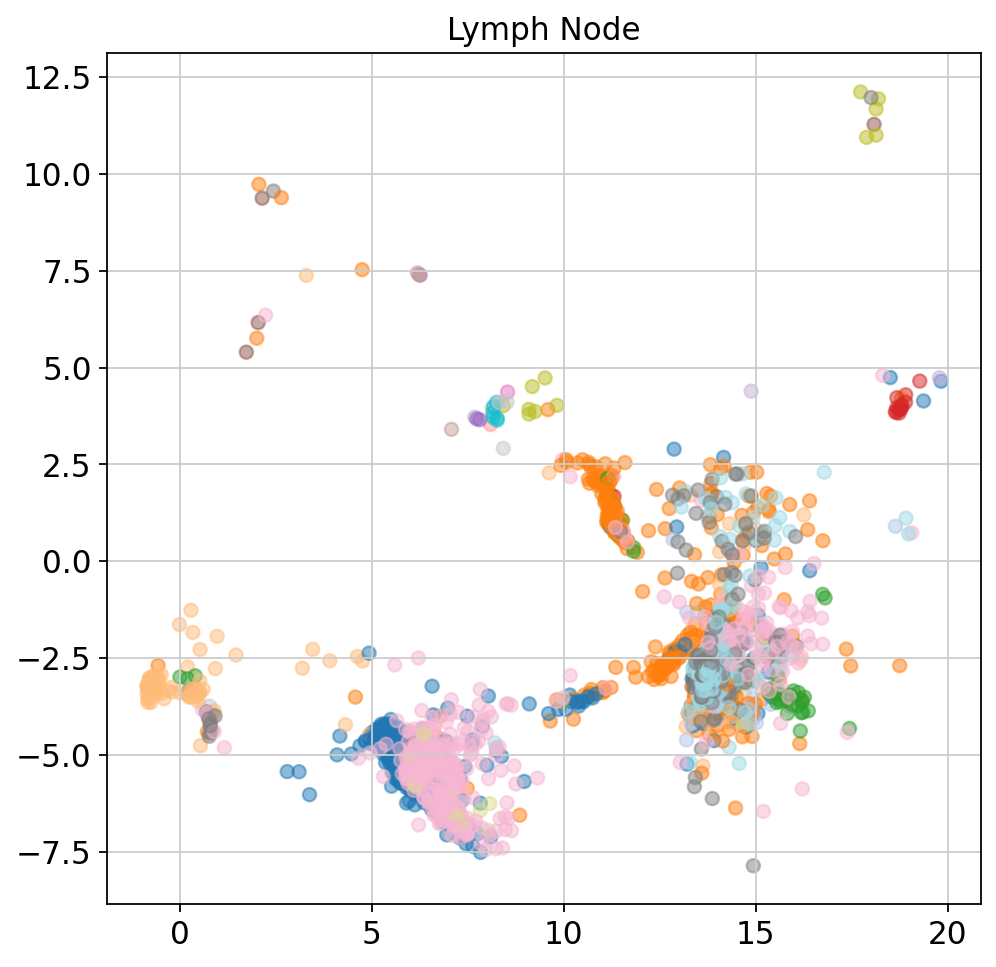

In [25]:
# Create a list of patches to use as handles in the legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=annotation_to_color[annotation], label=annotation) for annotation in annotations]

# plt scatter plot of umap1 vs umap2 and color by free_annotation
plt.figure(figsize=(7,7))
plt.scatter(umap["UMAP1"], umap["UMAP2"], c=umap["color"], cmap="tab20", alpha=0.5)
plt.title("Lymph Node")
plt.show()

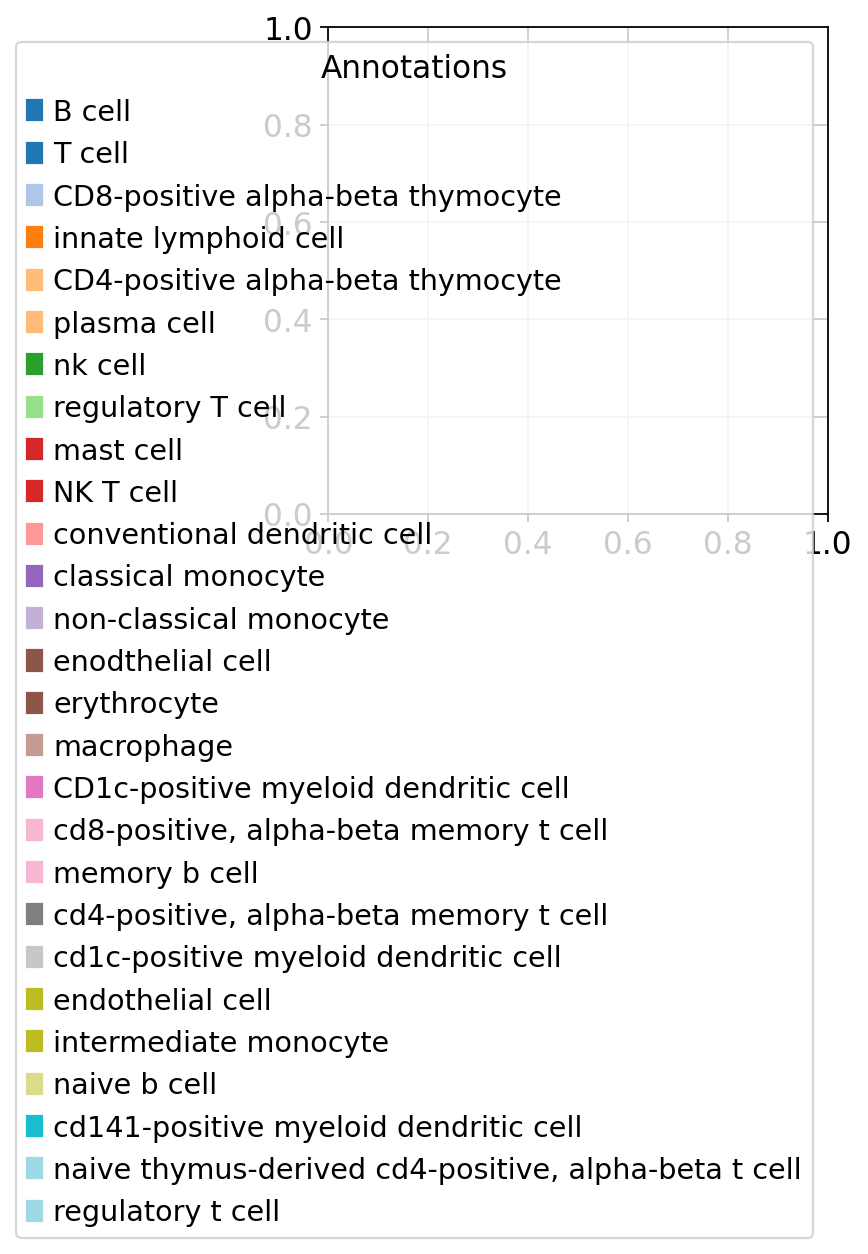

In [26]:
plt.legend(handles=legend_handles, title='Annotations')
